In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

In [73]:
# Mapper
vendor = {1:'Creative Mobile Technologies, LLC',2:'Curb Mobility, LLC',6:'Myle Technologies Inc',7:'Helix'}

rate_code = {1:'Std Rate', 2:'JFK', 3:'Newark', 4:'Nassau or Westchester', 5:'Negotiated Fare', 6:'Group Ride'
             , 7:'Null/Unknown'}


payment = {0:'Flex Fare trip', 1:'Credit Card', 2:'Cash', 3:'No Charge', 4:'Dispute', 5:'Unknown', 6:'Voided Trip'}
payment_color_cd = {0:'#B84E14', 1:'#32B857', 2:'#35B2B8', 3:'#4743B8', 4:'#B71E43', 5:'#505050', 6:'#000000'}

In [106]:
# importing data
df = pd.read_csv('Yellow_Taxi_Assignment.csv')

# mapping descriptions to codes
df['Vendor_desc'] = df['VendorID'].map(vendor)
df['Rate_desc'] = df['RatecodeID'].map(rate_code)
df['Payment_desc'] = df['payment_type'].map(payment)
df['Payment_color'] = df['payment_type'].map(payment_color_cd)

# type casting and extracting date information for histograms
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
df['trip_duration (minutes)'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
df['pickup_year'] = df['tpep_pickup_datetime'].dt.year
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

df.dtypes

VendorID                            int64
tpep_pickup_datetime       datetime64[us]
tpep_dropoff_datetime      datetime64[us]
passenger_count                   float64
trip_distance                     float64
RatecodeID                        float64
store_and_fwd_flag                    str
PULocationID                        int64
DOLocationID                        int64
payment_type                        int64
fare_amount                       float64
extra                             float64
mta_tax                           float64
tip_amount                        float64
tolls_amount                      float64
improvement_surcharge             float64
total_amount                      float64
congestion_surcharge              float64
airport_fee                       float64
Vendor_desc                           str
Rate_desc                             str
Payment_desc                          str
Payment_color                         str
trip_duration (minutes)           

In [107]:
# min and max for pick up time
print('Pick-up times: min and max')
print('-'*30)
print('min date: ', df['tpep_pickup_datetime'].min())
print('max date: ', df['tpep_pickup_datetime'].max())
print('-'*30)

Pick-up times: min and max
------------------------------
min date:  2018-01-01 00:25:49
max date:  2023-01-31 23:57:28
------------------------------


In [76]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,trip_duration (minutes),pickup_year,pickup_month,pickup_day,pickup_hour
count,304978.000000,304978,304978,295465.000000,304978.000000,295465.000000,304978.000000,304978.000000,304978.000000,304978.000000,...,304978.000000,304978.000000,304978.000000,232346.000000,106217.000000,304978.000000,304978.000000,304978.000000,304978.000000,304978.000000
mean,1.672786,2020-07-16 11:54:50.074785,2020-07-16 12:11:31.905308,1.479126,4.587589,1.142931,163.744975,160.988898,1.240463,13.510189,...,0.390715,0.312725,19.050501,2.241650,0.085815,16.697175,2020.049148,6.409875,15.610975,13.923408
min,1.000000,2018-01-01 00:25:49,2018-01-01 00:38:59,0.000000,-16.860000,1.000000,1.000000,1.000000,0.000000,-197.000000,...,-13.750000,-1.000000,-198.550000,-2.500000,-1.250000,-44.133333,2018.000000,1.000000,1.000000,0.000000
25%,1.000000,2019-04-08 09:18:22.500000,2019-04-08 09:32:34.750000,1.000000,1.000000,1.000000,121.000000,107.000000,1.000000,6.500000,...,0.000000,0.300000,10.800000,2.500000,0.000000,6.600000,2019.000000,3.000000,8.000000,10.000000
50%,2.000000,2020-07-17 17:01:39,2020-07-17 17:17:55,1.000000,1.730000,1.000000,162.000000,162.000000,1.000000,9.500000,...,0.000000,0.300000,14.300000,2.500000,0.000000,11.016667,2020.000000,6.000000,15.000000,14.000000
75%,2.000000,2021-10-24 11:29:50.500000,2021-10-24 11:42:53.250000,2.000000,3.210000,1.000000,234.000000,234.000000,2.000000,15.000000,...,0.000000,0.300000,20.760000,2.500000,0.000000,18.050000,2021.000000,9.000000,23.000000,18.000000
max,6.000000,2023-01-31 23:57:28,2023-02-01 00:09:12,6.000000,177247.400000,99.000000,265.000000,265.000000,5.000000,455.000000,...,96.550000,1.000000,561.490000,2.750000,1.250000,1439.866667,2023.000000,12.000000,31.000000,23.000000
std,0.514069,NaN,NaN,1.108255,434.226624,2.969941,66.570490,70.975905,0.528257,12.636651,...,1.699547,0.110404,15.464014,0.791877,0.318628,59.903429,1.453372,3.494127,8.726715,5.719368


In [77]:
# no need for normalization on count because number of rows per year are the same if not very similar for full years.
df.groupby('pickup_year')['VendorID'].count()

pickup_year
2018    59995
2019    59998
2020    59998
2021    59998
2022    59988
2023     5001
Name: VendorID, dtype: int64

# Payment Types
- We see that Cash is declining from 2018 on wards.
- Flex Fares eat into Credit Card's share of payment types in 2019.
- From 2020 on Credit Cards rebound while Cash and Flex Fares decline further.
- Other Payment types are insignificant.

In [126]:
df.groupby('Payment_desc').agg({'trip_distance':['min', 'max','mean','median'], 'VendorID':'count'})

trip_distance                              VendorID
                         min        max       mean median    count
Payment_desc                                                      
Cash                    0.00     129.35   2.858682   1.53    75899
Credit Card             0.00     172.22   3.087529   1.77   216662
Dispute                 0.00      26.70   2.538570   1.12     1140
Flex Fare trip        -16.86  177247.40  53.215937   4.50     9513
No Charge               0.00      27.60   2.300153   0.98     1763
Unknown                 0.00       0.00   0.000000   0.00        1

# Fare Amount vs Trip Distance by Payment Type
- Here we see the relationship between Fare Amount and Trip distance.
- Unsurprisingly there's a strong correlation.
- One thing that did surprise me was the vertical line at `$52` on the Fare Amount axis.
- Based on the Rate Type this turns out to be 98.7% JFK related trips with other trips coincedentally landing on the `$52` Fare Amount.

Payment_desc,Cash,Credit Card,Dispute,Flex Fare trip,No Charge,Unknown
pickup_year,,,,,,
2018,17829.0,41742.0,83.0,38.0,303.0,NaN
2019,16171.0,43074.0,136.0,299.0,318.0,NaN
2020,16139.0,39189.0,260.0,3929.0,481.0,NaN
2021,13006.0,43426.0,231.0,3017.0,317.0,1.0
2022,11843.0,45344.0,383.0,2107.0,311.0,NaN
2023,911.0,3887.0,47.0,123.0,33.0,NaN


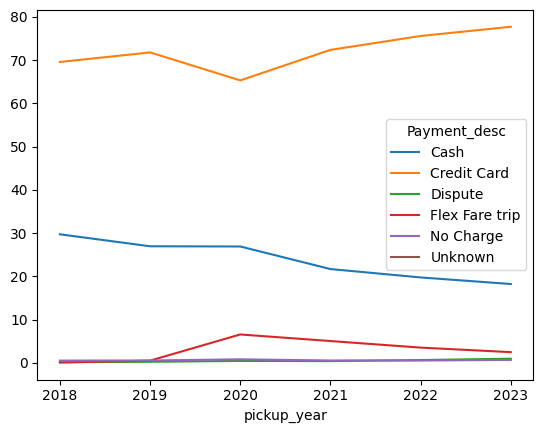

In [150]:
payment_distribution = df.pivot_table(index='pickup_year', columns='Payment_desc', values='VendorID', aggfunc='count')

payment_distribution_pct = (
    payment_distribution
    .div(payment_distribution.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)

payment_distribution_pct.plot(kind='line')
payment_distribution

In [118]:
flex_fare_share = df.pivot_table(index='Payment_desc',columns='Vendor_desc', values='VendorID',aggfunc='count', margins=True)
curb_ff = flex_fare_share.loc['Flex Fare trip']['Curb Mobility, LLC']
creative_mobility_ff = flex_fare_share.loc['Flex Fare trip']['Creative Mobile Technologies, LLC']
curb_total = flex_fare_share.loc['All']['Curb Mobility, LLC']
creative_mobility_total = flex_fare_share.loc['All']['Creative Mobile Technologies, LLC']

print('-'*30)
print(f'Curb Mobility\'s Flex Fare trips share is: {curb_ff / curb_total:.2%}')
print(f'Creative Mobility\'s Flex Fare trips share is: {creative_mobility_ff / creative_mobility_total:.2%}')
print()
print('Note: Flex Fare trips show no passenger count.')
print(' '*5,'It is a pre arranged trip where the route has already been priced similar to ride hailing like uber or lyft.')
print('-'*30)

------------------------------
Curb Mobility's Flex Fare trips share is: 3.84%
Creative Mobility's Flex Fare trips share is: 1.23%

Note: Flex Fare trips show no passenger count.
      It is a pre arranged trip where the route has already been priced similar to ride hailing like uber or lyft.
------------------------------


In [152]:
import plotly.express as px

fig = px.scatter(
    fare_distance,
    x='fare_amount',
    y='trip_distance',
    color='Payment_desc',
    opacity=0.5,
    title='Fare Amount vs Trip Distance by Payment Type',
    labels={
        'fare_amount': 'Fare Amount',
        'trip_distance': 'Trip Distance',
        'Payment_desc': 'Payment Type'
    }
)

# vertical line at JFK pricing
fig.add_vline(
    x=52,
    line_dash='dot',
    annotation_text='JFK pricing',
    annotation_position='bottom right',
    opacity=0.2,
)

fig.show()

In [175]:
df.query('fare_amount == 52')['Rate_desc'].value_counts()

Rate_desc
JFK                      7045
Std Rate                   78
Negotiated Fare             7
Newark                      1
Nassau or Westchester       1
Name: count, dtype: int64

# Hourly Pick-up Patterns by Year
- In 2018 and 2019 there is little change in daily pick-up patterns.
- In 2020 and 2021 the distribution changes towards the middle of the day and reduces at night.
- In 2022 the distribution looks a lot more like pre-Covid although there are more trips during the day compared to 2018 and 2019.
- While 2023 data exists for (only) January, I don't have enough data to assess a change in behavior or usage patterns.

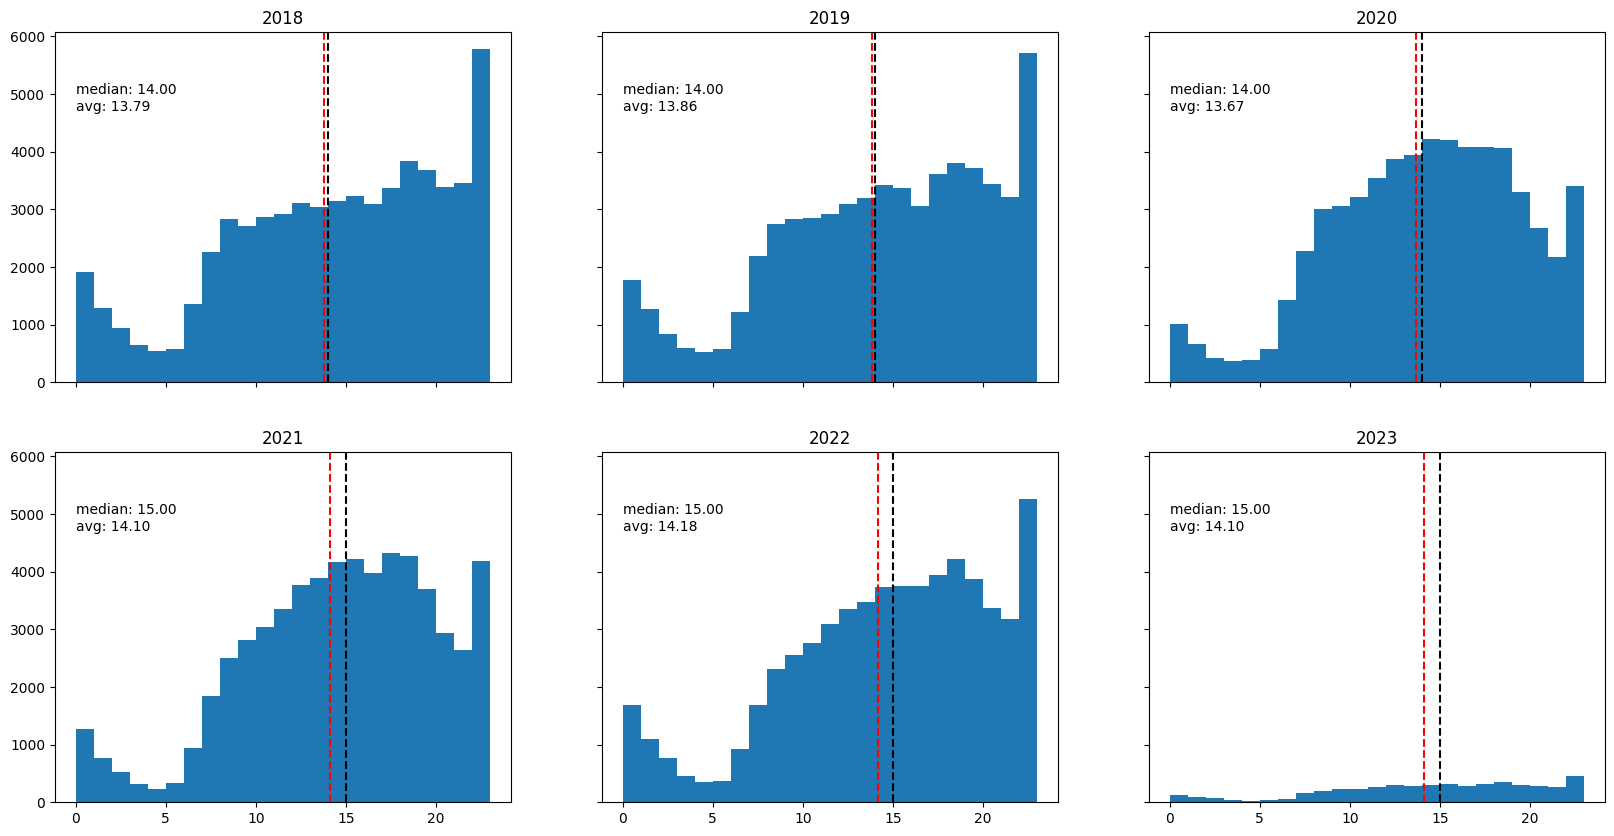

In [176]:
years = df['pickup_year'].unique()

fig, ax = plt.subplots(nrows=2, ncols=3, sharey=True, sharex=True, figsize=(20,10))

for axis, years in zip(ax.flatten(), years):
    data = df.loc[df['pickup_year'] == years, 'pickup_hour']
    median = data.median()
    mean = data.mean()
    axis.hist(data, bins=23)
    axis.axvline(median, color='k', linestyle='dashed')
    axis.axvline(mean, color='r', linestyle='dashed')
    axis.set_title(years)
    axis.annotate(text=f'median: {median:.2f}', xy=(0, 5000))
    axis.annotate(text=f'avg: {mean:.2f}', xy=(0, 4700))

# plt.tight_layout()
plt.show()


# Hourly Pick-up Patterns by Rate Types
- Showing hourly distribution of Rate Types excl. Std Rate because that is the most common by far and made everything else unreadable.
- JFK Airport rides have two distinct humps, one in the morning from 5-9 o'clock and 13-17 o'clock. The earlier hump may be attributable to people going to the airport for flights bound to Europe and the afternoon hump is related to domestic air travel.
- Negotiated Fares and trips to Newark, Nassau and Westchester are pretty evenly distributed. The trips make up about 3%-4% of fare amount

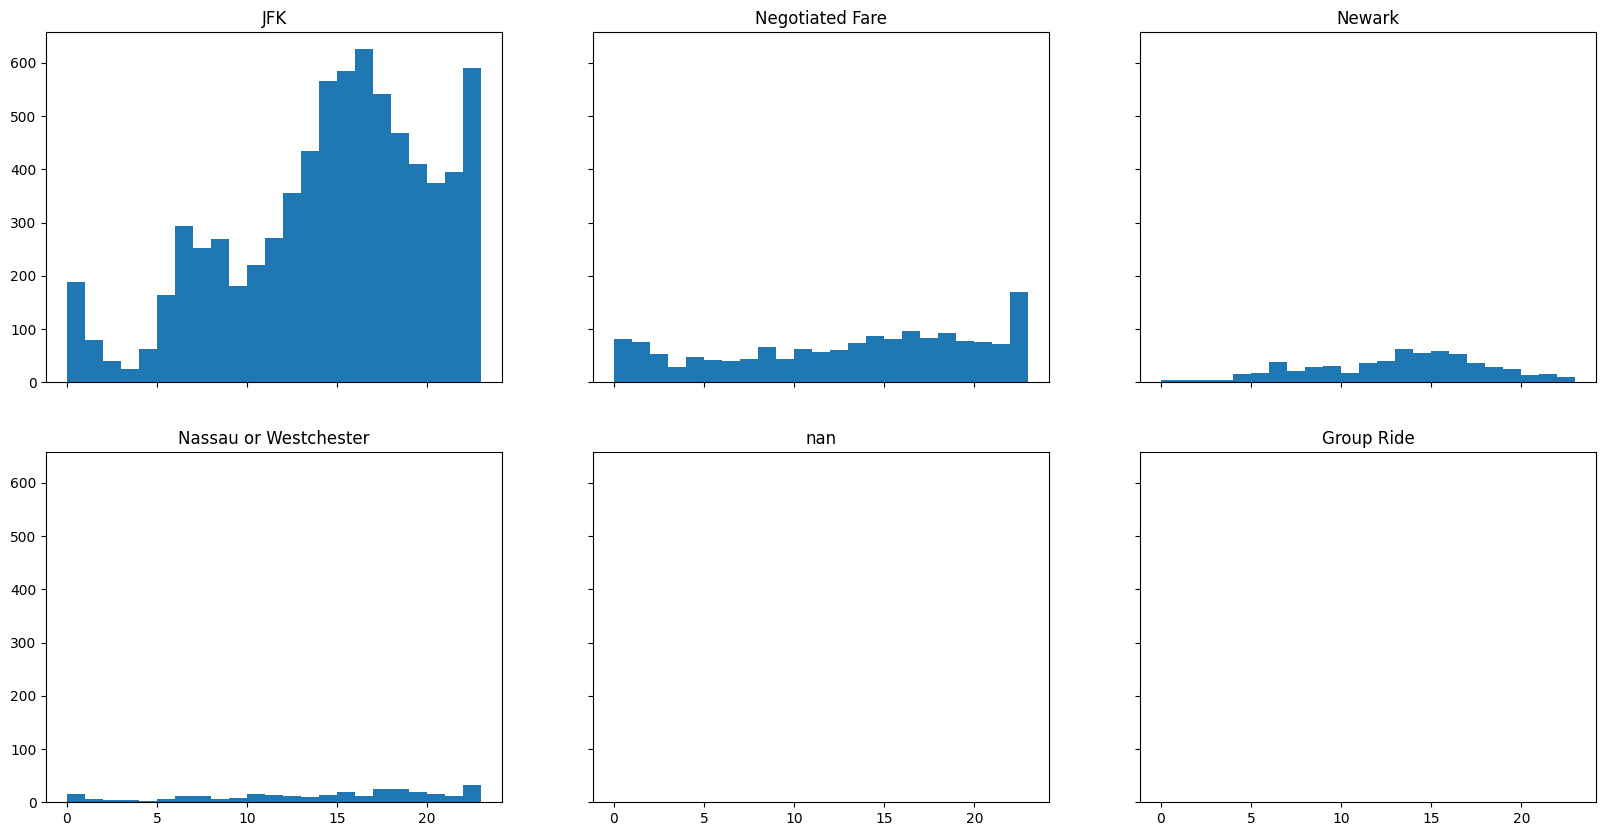

------------------------------
Rate_desc
Std Rate                 285278
JFK                        7389
Negotiated Fare            1607
Newark                      621
Nassau or Westchester       301
Group Ride                    1
Name: count, dtype: int64


In [189]:
rc = df[df['Rate_desc'] != 'Std Rate']['Rate_desc'].unique()

fig, ax = plt.subplots(nrows=2, ncols=3, sharey=True, sharex=True, figsize=(20, 10))

for axis, rate in zip(ax.flatten(), rc):
    data = df.loc[df['Rate_desc'] == rate, 'pickup_hour']
    median = data.median()
    mean = data.mean()
    axis.hist(data, bins=23)#, density=True)
    axis.set_title(rate)

# plt.tight_layout()
plt.show()
print('-'*30)
print(df['Rate_desc'].value_counts())

# Trip Profile
Trip Distance, Duration and Total Trip Amounts are heavily skewed towards the left. Most trips only last a few minutes and cost a few dollars.

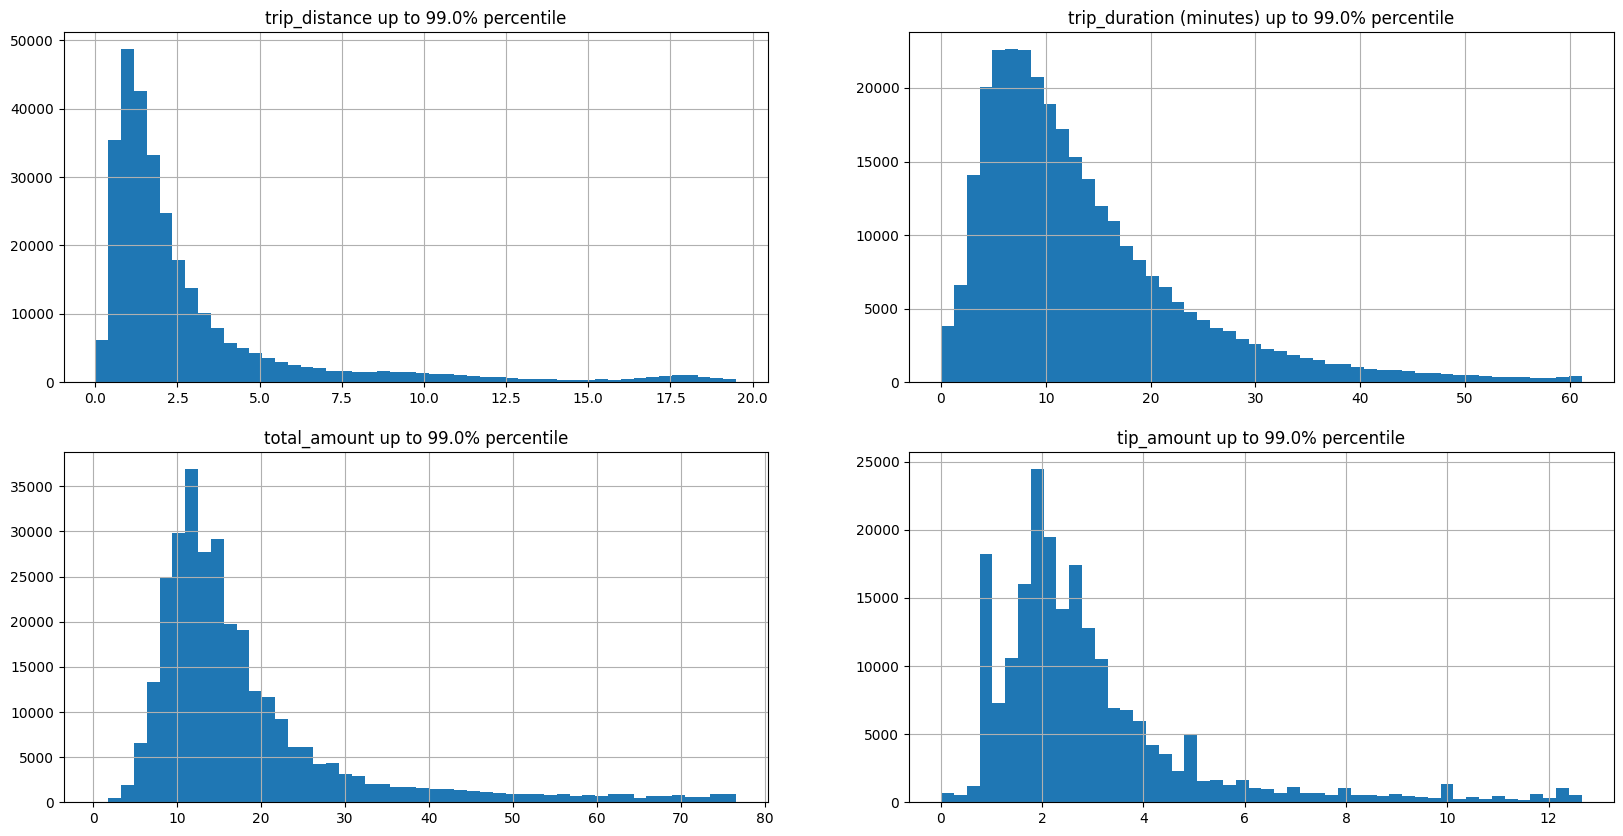

In [87]:
qtile = 0.99
cols = ['trip_distance','trip_duration (minutes)','total_amount','tip_amount']

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(20,10))

for axis, cols in zip(ax.flatten(), cols):
    upper = df[cols].quantile(qtile)
    f_df = df[(df[cols] > 0) & (df[cols] <= upper)]
    f_df[cols].hist(bins=50, ax=axis)
    axis.set_title(f'{cols} up to {qtile:.1%} percentile', fontsize=12)

plt.show()

# Insights about Vendor ridership and revenue
- no Helix VendorID in dataset
- Myle Tech does not show passenger information because they are Flex Fare. Flex Fare does not record rider information. Add'l it was founded in 2020 and only have 521 Rides in the dataset while other Vendors have thousands of rides.
- Flex Fare allows NYC yellow taxi passengers to have upfront pricing similar to ride-hailing services like Uber and Lyft.
- Ridership has not recovered to pre-covid levels in total
- Creative Mobile Tech saw a decrease of 24% in revenue from 2018 to 2022 (2018: 316204, 2022: 240684)
- Ridership for Creative Mobility dropped 32% from 2018 to 2022 (2018: 24877, 2022: 17007)
- Curb Mobility saw an increase of 37% in revenue from 2018 to 2022 (2018: 467687, 2022: 640886)
- Ridership for Curb Mobility increased by 23% from 2018 to 2022 (2018: 34804, 2022: 42888)
- Curb Mobility seems to have strengthened it's position even though Taxi Ridership is declining
- Both companies have increased their revenue per ride since revenue either decreased less or increased more compared to ridership

In [166]:
df.pivot_table(index=['Vendor_desc'], columns='pickup_year',values='fare_amount', aggfunc='sum', margins=True)

pickup_year,2018,2019,2020,2021,2022,2023,All
Vendor_desc,,,,,,,
"Creative Mobile Technologies, LLC",316204.66,278708.27,229289.15,229858.06,240684.15,23439.48,1318183.77
"Curb Mobility, LLC",467687.81,523739.46,523262.29,552751.12,640886.65,67647.84,2775975.17
Myle Technologies Inc,NaN,NaN,4295.16,11464.39,3842.67,NaN,19602.22
All,783892.47,802447.73,756846.60,794073.57,885413.47,91087.32,4113761.16


Vendor_desc,"Creative Mobile Technologies, LLC","Curb Mobility, LLC",Myle Technologies Inc,All
pickup_year,,,,
2018,24877.0,34804.0,NaN,59681
2019,21437.0,38374.0,NaN,59811
2020,20036.0,39813.0,149.0,59998
2021,18158.0,41559.0,279.0,59996
2022,17007.0,42888.0,93.0,59988
2023,1371.0,3630.0,NaN,5001
All,102886.0,201068.0,521.0,304475


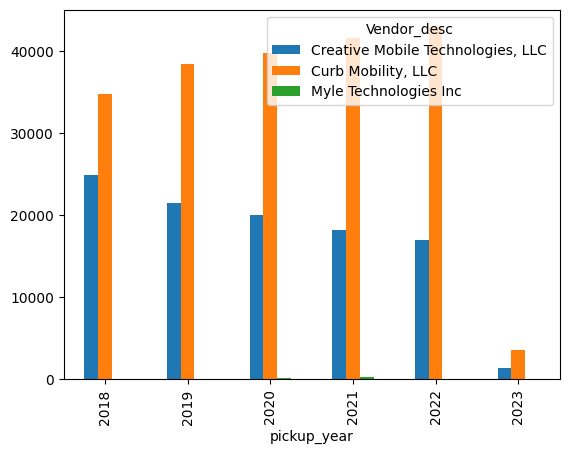

In [167]:
df.pivot_table(index='pickup_year', columns='Vendor_desc',values='VendorID', aggfunc='count').plot(kind='bar')
df.pivot_table(index='pickup_year', columns='Vendor_desc',values='VendorID', aggfunc='count', margins=True)

# plt.title('Ridership has not recovered to pre-covid levels\n2022 Ridership is 85% of 2018 Ridership')

# High Revenue Pick-up Locations
- Below are the top 10 Pick-up Locations.
- These locations are not only valuable as pickup points, but also as destination points. By filtering trips where the drop-off location is one of the top revenue-generating pickup locations, we can estimate how much inbound taxi activity feeds into these high-value zones.
- This helps identify whether top pickup locations are also strong demand destinations, meaning they both attract passengers and generate future outbound trips.
- We see for example 132 ranking as the best pick-up location and second best dorp-off location. It acts as a two-sided taxi demand hub: people frequently travel to the area, and the area also generates valuable outbound trips.

In [190]:
# 10 most important pick-up locations based on fare_amount
top_fare_amt = df.groupby(by=['PULocationID']).agg({'fare_amount':'sum', 'tip_amount':'sum', 'total_amount':'sum'}).sort_values(ascending=False,by='fare_amount').head(10)

top_fare_amt['tip_pct'] = round(top_fare_amt['tip_amount'] / top_fare_amt['total_amount'] * 100, 4)
top_fare_amt

,fare_amount,tip_amount,total_amount,tip_pct
PULocationID,,,,
132,440950.33,61138.45,557482.37,10.9669
138,220543.31,40002.50,307186.34,13.0222
161,132434.50,23984.33,194507.35,12.3308
237,131410.05,24882.31,200389.24,12.4170
186,128116.93,21571.64,184150.75,11.7141
236,126518.56,23710.78,190447.62,12.4500
230,114606.53,19276.01,163679.59,11.7767
162,114017.74,21439.33,168669.88,12.7108
48,107909.67,17669.32,155896.67,11.3340


In [191]:
# matches the Pick up top 10 exaclty because I am matching them on Index
top_fare_amt_drop_off_index = top_fare_amt.index
top_fare_amt_drop_off = df[df['DOLocationID'].isin(top_fare_amt_drop_off_index)]

gb_top_fare_drop_off = top_fare_amt_drop_off.groupby('DOLocationID').agg({'fare_amount':'sum', 'tip_amount':'sum', 'total_amount':'sum'}).sort_values(ascending=False,by='fare_amount')

gb_top_fare_drop_off

,fare_amount,tip_amount,total_amount
DOLocationID,,,
236,125921.77,24773.53,193460.63
132,119279.80,19432.42,155363.74
161,113143.45,20181.42,166807.86
237,110886.41,21346.89,170654.39
230,102325.35,16086.20,145981.72
170,97010.48,17960.03,145545.09
48,96462.26,16101.84,141151.33
162,91840.32,17135.18,136041.02
138,91435.84,18124.75,129927.62


In [192]:
# True top 10 of Dorp off locations by Fare Amount
drop_off_top_fare_amt = df.groupby(by=['DOLocationID']).agg({'fare_amount':'sum', 'tip_amount':'sum', 'total_amount':'sum'}).sort_values(ascending=False,by='fare_amount').head(10)
drop_off_top_fare_amt

,fare_amount,tip_amount,total_amount
DOLocationID,,,
236,125921.77,24773.53,193460.63
132,119279.80,19432.42,155363.74
161,113143.45,20181.42,166807.86
237,110886.41,21346.89,170654.39
230,102325.35,16086.20,145981.72
170,97010.48,17960.03,145545.09
48,96462.26,16101.84,141151.33
162,91840.32,17135.18,136041.02
138,91435.84,18124.75,129927.62


In [201]:
pu_tfa = top_fare_amt.index.tolist()
do_tfa = drop_off_top_fare_amt.index.tolist()
intersection = list(set(pu_tfa) & set(do_tfa))

print('Here is the intersection between the pick-up and drop-off locations:')
print(f'pick-up locations: {pu_tfa}')
print(f'drop-off locations: {do_tfa}')
print(f'intersection of locations: {intersection}')

Here is the intersection between the pick-up and drop-off locations:
pick-up locations: [132, 138, 161, 237, 186, 236, 230, 162, 48, 170]
drop-off locations: [236, 132, 161, 237, 230, 170, 48, 162, 138, 142]
intersection of locations: [161, 162, 132, 230, 170, 138, 236, 237, 48]


# Investigation into Myle
Myle didn't have passenger count information while still showing fare amounts and trip distance. This was very confusing until I understood more about what the Flex Fare Rate Code is. More information related to that has already been shared above.

In [170]:
df.query('VendorID == 6')

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,airport_fee,Vendor_desc,Rate_desc,Payment_desc,Payment_color,trip_duration (minutes),pickup_year,pickup_month,pickup_day,pickup_hour
156293,6,2020-08-09 16:08:47,2020-08-09 17:08:30,NaN,9.66,NaN,NaN,265,39,0,...,NaN,Myle Technologies Inc,NaN,Flex Fare trip,#B84E14,59.716667,2020,8,9,16
160883,6,2020-09-07 19:09:51,2020-09-07 20:09:14,NaN,3.60,NaN,NaN,265,71,0,...,NaN,Myle Technologies Inc,NaN,Flex Fare trip,#B84E14,59.383333,2020,9,7,19
160966,6,2020-09-08 13:09:42,2020-09-08 14:09:44,NaN,4.22,NaN,NaN,265,36,0,...,NaN,Myle Technologies Inc,NaN,Flex Fare trip,#B84E14,60.033333,2020,9,8,13
161035,6,2020-09-08 10:09:54,2020-09-08 11:09:55,NaN,3.92,NaN,NaN,265,196,0,...,NaN,Myle Technologies Inc,NaN,Flex Fare trip,#B84E14,60.016667,2020,9,8,10
161115,6,2020-09-09 05:09:33,2020-09-09 05:09:09,NaN,3.98,NaN,NaN,265,136,0,...,NaN,Myle Technologies Inc,NaN,Flex Fare trip,#B84E14,-0.400000,2020,9,9,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293121,6,2022-11-18 08:11:10,2022-11-18 09:11:00,NaN,17.50,NaN,NaN,265,86,0,...,NaN,Myle Technologies Inc,NaN,Flex Fare trip,#B84E14,59.833333,2022,11,18,8
293781,6,2022-11-23 22:11:41,2022-11-23 23:11:18,NaN,10.85,NaN,NaN,265,155,0,...,NaN,Myle Technologies Inc,NaN,Flex Fare trip,#B84E14,59.616667,2022,11,23,22
293974,6,2022-11-24 12:11:58,2022-11-24 13:11:24,NaN,18.37,NaN,NaN,265,219,0,...,NaN,Myle Technologies Inc,NaN,Flex Fare trip,#B84E14,59.433333,2022,11,24,12
294716,6,2022-11-29 06:11:17,2022-11-29 06:11:54,NaN,7.49,NaN,NaN,265,209,0,...,NaN,Myle Technologies Inc,NaN,Flex Fare trip,#B84E14,0.616667,2022,11,29,6


In [171]:
df[df['VendorID'] == 6]['Payment_desc'].value_counts()

Payment_desc
Flex Fare trip    521
Name: count, dtype: int64

## Questions that have already been answered
What are the passenger counts for Flexfare rides?<br>
```df.query('Payment_desc == "Flex Fare trip"')['passenger_count'].value_counts()```<br>
Flex Fare Rides seem to not have passenger counts, but show Fare information, trip distance etc..

In [172]:
df.query('Payment_desc == "Flex Fare trip"')['passenger_count'].value_counts()

Series([], Name: count, dtype: int64)